In [2]:
import math 
import numpy as np
import matplotlib.pyplot as plt
%pip install graphviz
%matplotlib inline


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [87]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [133]:
class Value:
    def __init__(self,data,_children=(),_op="",label=""):
        self.data = data
        self._prev = set(_children)
        self._op = _op 
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other),"+")

        # perform backpropagation on the output of this addition operation
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad

        out._backward = _backward

        return out
    
    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)
    
    def __neg__(self):
        return self * -1
    
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),"*")

        def _backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,),"**")

        def _backward():
            # power rule: d/dx x^n = n * x^(n-1)
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t,(self,),"tanh")

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),"exp")

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [134]:
# inputs
x1 = Value(2.0,label="x1")
x2 = Value(0.0,label="x2")

#weights 
w1 = Value(-3.0,label="w1")
w2 = Value(1.0,label="w2")

bias = Value(6.881373587019543,label="b")
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1 + x2w2"
n = x1w1x2w2 + bias; n.label = "n"

o = n.tanh(); o.label = "o"


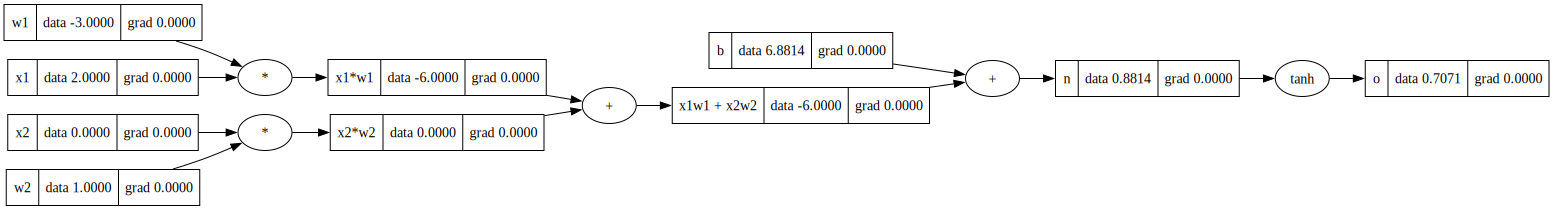

In [135]:
draw_dot(o)

In [136]:
o.backward()

In [185]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(np.random.uniform(-1,1))

    def __call__(self,x):
        # compute the weighted sum 
        # w * x + b 
        act = sum((wi * xi for wi,xi in zip(self.w, x)),self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [186]:
x = [2.0, 3.0,-1.0]
m = MLP(3, [4, 4, 1])
m(x)  

Value(data=0.9848069926570149)

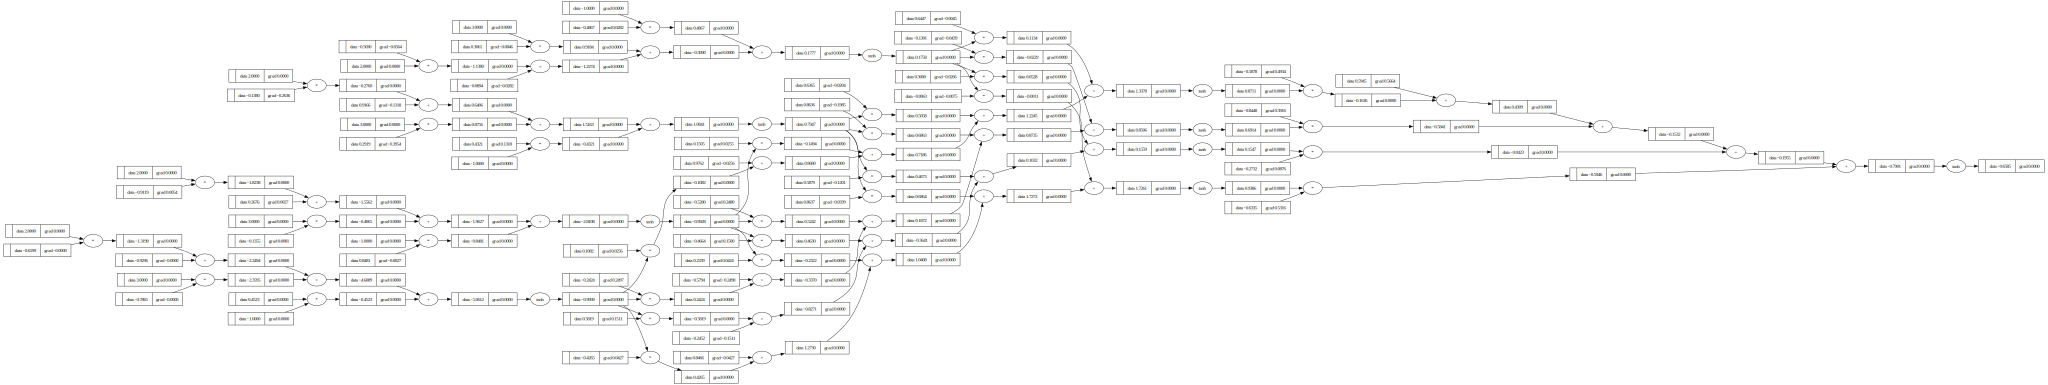

In [166]:
draw_dot(m(x))

In [234]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [325]:
for k in range(100):
    # forward pass
    ypred =[m(x) for x in xs]
    loss = sum([(yout - ygt) ** 2 for ygt,yout in zip(ys, ypred)])

    loss.backward()

    for p in m.parameters():
        p.data += -0.01 * p.grad

    print(k, loss.data)

0 5.827389237863411e-07
1 9.659966856013134e-08
2 4.4289577305120705e-08
3 2.0818420636082465e-08
4 9.789991238939412e-09
5 4.603831120128509e-09
6 2.164981793618452e-09
7 1.0180933342626456e-09
8 4.787636440878985e-10
9 2.2514492559088053e-10
10 1.0589038067430776e-10
11 4.985092959432528e-11
12 2.3687531053851598e-11
13 1.2457283169998037e-11
14 1.4330299518179576e-11
15 6.836493980728347e-11
16 4.99278244006773e-10
17 3.5700565899260243e-09
18 2.1846138297414397e-08
19 1.0134819042602747e-07
20 2.756189204501803e-07
21 2.443622328956963e-07
22 5.1830817604130454e-08
23 2.313278162618597e-09
24 7.362060066308234e-11
25 3.82594101603188e-12
26 4.925485975285305e-13
27 1.9923923182955357e-13
28 1.442837690273762e-13
29 1.2880233802292535e-13
30 1.228179790837981e-13
31 1.18536729584443e-13
32 1.1344701121382348e-13
33 1.0689955725832302e-13
34 9.901722334200279e-14
35 9.021862213200073e-14
36 8.098301968928997e-14
37 7.173888933827286e-14
38 6.282081779663555e-14
39 5.446271459987763e-

In [326]:
ypred

[Value(data=1.0),
 Value(data=-0.9999999996807548),
 Value(data=-0.9999999996808951),
 Value(data=1.0)]